# 속도 데이터 분석 및 벡터 변환

In [2]:
import os
import glob
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

np.set_printoptions(threshold=np.inf, linewidth=200, suppress=True)

import torch
from common.quaternion import cont6d_to_matrix_np, matrix_to_quat, qeuler_np, euler_to_quaternion

In [4]:
joint_names = [
    "left_hip", "right_hip", "spine1", "left_knee", "right_knee", "spine2",
    "left_ankle", "right_ankle", "spine3", "left_foot", "right_foot", "neck",
    "left_collar", "right_collar", "head", "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow", "left_wrist", "right_wrist"
]

## 1. 6D rotation에서 회전 행렬로 변환

In [56]:
'''
def cont6d_to_matrix_np(cont6d):
    q = torch.from_numpy(cont6d).contiguous().float()
    return cont6d_to_matrix(q).numpy()
    
    
def cont6d_to_matrix(cont6d):
    assert cont6d.shape[-1] == 6, "The last dimension must be 6"
    x_raw = cont6d[..., 0:3]
    y_raw = cont6d[..., 3:6]

    x = x_raw / torch.norm(x_raw, dim=-1, keepdim=True)
    z = torch.cross(x, y_raw, dim=-1)
    z = z / torch.norm(z, dim=-1, keepdim=True)

    y = torch.cross(z, x, dim=-1)

    x = x[..., None]
    y = y[..., None]
    z = z[..., None]

    mat = torch.cat([x, y, z], dim=-1)
    return mat
'''

'\ndef cont6d_to_matrix_np(cont6d):\n    q = torch.from_numpy(cont6d).contiguous().float()\n    return cont6d_to_matrix(q).numpy()\n    \n    \ndef cont6d_to_matrix(cont6d):\n    assert cont6d.shape[-1] == 6, "The last dimension must be 6"\n    x_raw = cont6d[..., 0:3]\n    y_raw = cont6d[..., 3:6]\n\n    x = x_raw / torch.norm(x_raw, dim=-1, keepdim=True)\n    z = torch.cross(x, y_raw, dim=-1)\n    z = z / torch.norm(z, dim=-1, keepdim=True)\n\n    y = torch.cross(z, x, dim=-1)\n\n    x = x[..., None]\n    y = y[..., None]\n    z = z[..., None]\n\n    mat = torch.cat([x, y, z], dim=-1)\n    return mat\n'

In [57]:
def convert_6d_to_rotmat(rot_data_6d):
    """
    6D rotation representation을 회전 행렬로 변환
    
    Args:
        rot_data_6d: (seq_len, 126) 또는 (seq_len, 21, 6) 형태의 6D rotation 데이터
    
    Returns:
        rot_matrix: (seq_len, 21, 3, 3) 형태의 회전 행렬
    """
    # 1. 입력 형태 확인 및 변환
    if len(rot_data_6d.shape) == 2:
        # (seq_len, 126) → (seq_len, 21, 6)
        rot_data_6d = rot_data_6d.reshape(-1, 21, 6)
    
    # 2. 6D → Rotation Matrix
    rot_matrix = cont6d_to_matrix_np(rot_data_6d)  # (seq_len, 21, 3, 3)
    
    return rot_matrix

전체 파일에 대해 회전 행렬 변환

In [58]:
input_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/new_joint_vecs'
rotmat_output_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/01_rot_mat'
os.makedirs(rotmat_output_dir, exist_ok=True)

input_files = sorted(glob.glob(os.path.join(input_dir, '*.npy')))

for input_file in tqdm(input_files, desc="Processing files"):
    filename = os.path.basename(input_file)
    out_file = os.path.join(rotmat_output_dir, filename)

    data = np.load(input_file)                 # (T, 263)
    rot_data_6d = data[:, 67:193]              # (T, 126)
    rot_data_6d = rot_data_6d.reshape(-1, 21, 6)  # (T, 21, 6)

    rot_matrix = convert_6d_to_rotmat(rot_data_6d)  # (T, 21, 3, 3)
    np.save(out_file, rot_matrix.astype(np.float32))

Processing files: 100%|██████████| 29228/29228 [08:35<00:00, 56.74it/s]


In [59]:
# shape 확인
files = sorted(glob.glob(os.path.join(rotmat_output_dir, '*.npy')))
if len(files) == 0:
    raise FileNotFoundError(f"No .npy files found in: {rotmat_output_dir}")

f = files[0]
x = np.load(f)

print("file:", f)
print("shape:", x.shape, "dtype:", x.dtype)

# 기대 shape 체크 (T, 21, 3, 3)
if x.ndim == 4 and x.shape[1:] == (21, 3, 3):
    print("OK: looks like (T, 21, 3, 3)")
else:
    print("WARNING: unexpected shape, expected (T, 21, 3, 3)")

file: D:/HumanML3D-SMPL-main/HumanML3D/01_rot_mat\000000.npy
shape: (116, 21, 3, 3) dtype: float32
OK: looks like (T, 21, 3, 3)


## 2. 프레임 간 상대 회전 구하기

In [60]:
input_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/01_rot_mat'
output_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/02_rel_rot_mat'
os.makedirs(output_dir, exist_ok=True)

files = sorted(glob.glob(os.path.join(input_dir, '*.npy')))

for f in tqdm(files, desc="Computing relative rotations"):
    filename = os.path.basename(f)
    out_f = os.path.join(output_dir, filename)

    rot_matrix = np.load(f)  # (T, 21, 3, 3)

    R_t = rot_matrix[:-1]                          # (T-1, 21, 3, 3)
    R_next = rot_matrix[1:]                        # (T-1, 21, 3, 3)
    R_rel = R_next @ np.transpose(R_t, (0, 1, 3, 2))  # (T-1, 21, 3, 3)

    np.save(out_f, R_rel.astype(np.float32))

Computing relative rotations: 100%|██████████| 29228/29228 [03:53<00:00, 125.08it/s]


## 3. Log mapping

In [61]:
def so3_log_map(R, eps=1e-8):
    """
    R: (..., 3, 3) rotation matrices in SO(3)
    return: (..., 3) rotation vectors (axis * angle), unit = rad
    """
    tr = np.trace(R, axis1=-2, axis2=-1)  # (...,)
    cos_theta = (tr - 1.0) / 2.0
    cos_theta = np.clip(cos_theta, -1.0 + 1e-7, 1.0 - 1e-7)
    theta = np.arccos(cos_theta)  # (...,)

    # vee(R - R^T)
    w = np.stack([
        R[..., 2, 1] - R[..., 1, 2],
        R[..., 0, 2] - R[..., 2, 0],
        R[..., 1, 0] - R[..., 0, 1],
    ], axis=-1)  # (..., 3)

    sin_theta = np.sin(theta)

    # axis = w / (2 sin(theta))
    axis = w / (2.0 * sin_theta[..., None] + eps)

    # rotvec = theta * axis
    rotvec = axis * theta[..., None]  # (..., 3)

    # theta ~ 0 안정화: rotvec ≈ 0
    small = theta < 1e-5
    if np.any(small):
        rotvec[small] = 0.0

    return rotvec

In [62]:
input_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/02_rel_rot_mat'
output_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/03_log_map'
os.makedirs(output_dir, exist_ok=True)

files = sorted(glob.glob(os.path.join(input_dir, '*.npy')))

for f in tqdm(files, desc="SO(3) log-mapping to so(3)"):
    filename = os.path.basename(f)
    out_f = os.path.join(output_dir, filename)

    R_rel = np.load(f)  # (T-1, 21, 3, 3)
    rotvec = so3_log_map(R_rel).astype(np.float32)  # (T-1, 21, 3)

    np.save(out_f, rotvec)

SO(3) log-mapping to so(3): 100%|██████████| 29228/29228 [03:50<00:00, 126.74it/s]


## 4. 각속도 벡터 w (rad/s)

In [63]:
fps = 20

input_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/03_log_map'   # phi 저장된 폴더 (T-1, 21, 3)
output_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/04_omega'    # omega 저장 폴더
os.makedirs(output_dir, exist_ok=True)

files = sorted(glob.glob(os.path.join(input_dir, '*.npy')))

for f in tqdm(files, desc="Compute angular velocity (omega)"):
    filename = os.path.basename(f)
    out_f = os.path.join(output_dir, filename)

    phi = np.load(f)                      # (T-1, 21, 3) rad
    omega = (phi * fps).astype(np.float32)  # (T-1, 21, 3) rad/s

    np.save(out_f, omega)

Compute angular velocity (omega): 100%|██████████| 29228/29228 [04:21<00:00, 111.76it/s]


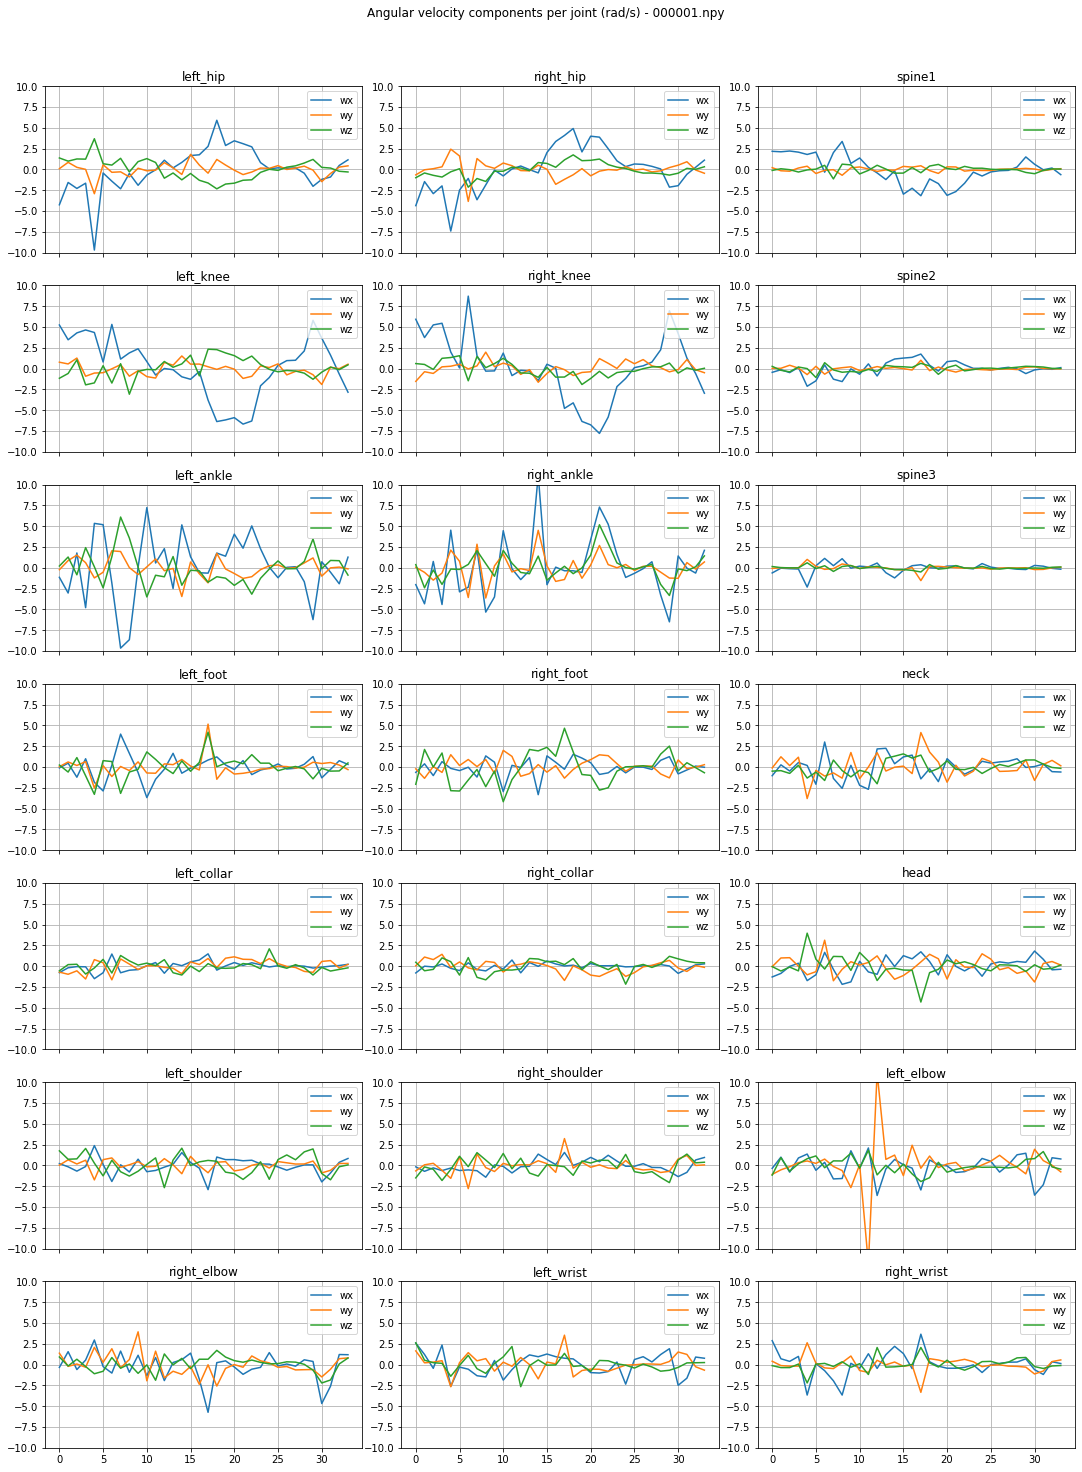

In [5]:
omega_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/04_omega'

# 여기서 보고 싶은 파일명 지정
file_name = "000001.npy"
omega_path = os.path.join(omega_dir, file_name)

omega = np.load(omega_path)  # (T-1, 21, 3)

T1, J, _ = omega.shape
assert J == 21
assert len(joint_names) == 21

t = np.arange(T1)

fig, axes = plt.subplots(7, 3, figsize=(15, 20), sharex=True)
axes = axes.flatten()

for j in range(21):
    ax = axes[j]
    ax.plot(t, omega[:, j, 0], label="wx")
    ax.plot(t, omega[:, j, 1], label="wy")
    ax.plot(t, omega[:, j, 2], label="wz")
    ax.set_title(joint_names[j])
    ax.set_ylim(-10.0, 10.0)
    ax.grid(True)
    ax.legend(loc="upper right")

fig.suptitle(f"Angular velocity components per joint (rad/s) - {file_name}", y=1.02)
plt.tight_layout()
plt.show()

## 5. 필요한 정보만 남기기

- 관절 : hip, knee, ankle, shoulder, elbow, wrist
- 움직임 정보를 하나로 합치기. (L2 norm)
    - Left, Right Hip : wx, wz
    - Left, Right Knee : wx
    - Left, Right Shoulder : wx, wz
    - Left, Right Elbow : wy

In [11]:
## 5. 필요한 정보만 남기고 L2 norm으로 합치기

# 관절별로 사용할 축 정의
joint_axis_config = {
    "left_hip": [0, 2],      # wx, wz
    "right_hip": [0, 2],     # wx, wz
    "left_knee": [0],        # wx
    "right_knee": [0],       # wx
    "left_shoulder": [0, 2], # wx, wz
    "right_shoulder": [0, 2],# wx, wz
    "left_elbow": [1],       # wy
    "right_elbow": [1],      # wy
}

selected_joint_names = list(joint_axis_config.keys())
selected_indices = [joint_names.index(name) for name in selected_joint_names]

print(f"Selected joint indices: {selected_indices}")
print(f"Selected joints: {selected_joint_names}")
print(f"\nAxis configuration:")
for joint, axes in joint_axis_config.items():
    axis_names = ['wx', 'wy', 'wz']
    selected_axes = [axis_names[i] for i in axes]
    print(f"  {joint:20s}: {selected_axes}")

Selected joint indices: [0, 1, 3, 4, 15, 16, 17, 18]
Selected joints: ['left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow']

Axis configuration:
  left_hip            : ['wx', 'wz']
  right_hip           : ['wx', 'wz']
  left_knee           : ['wx']
  right_knee          : ['wx']
  left_shoulder       : ['wx', 'wz']
  right_shoulder      : ['wx', 'wz']
  left_elbow          : ['wy']
  right_elbow         : ['wy']


In [128]:
omega_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/04_omega'
output_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/05_omega_l2norm'
os.makedirs(output_dir, exist_ok=True)

files = sorted(glob.glob(os.path.join(omega_dir, '*.npy')))

for f in tqdm(files, desc="Computing L2 norm for selected joints"):
    filename = os.path.basename(f)
    out_f = os.path.join(output_dir, filename)
    
    omega = np.load(f)  # (T-1, 21, 3)
    
    # 각 관절에 대해 L2 norm 계산
    omega_l2 = []
    
    for joint_name in selected_joint_names:
        joint_idx = joint_names.index(joint_name)
        axes = joint_axis_config[joint_name]
        
        # 해당 관절의 선택된 축들만 추출
        selected_components = omega[:, joint_idx, axes]  # (T-1, len(axes))
        
        # L2 norm 계산 (항상 양수)
        l2_norm = np.linalg.norm(selected_components, axis=1, keepdims=True)  # (T-1, 1)
        omega_l2.append(l2_norm)
    
    # (T-1, 8, 1) 형태로 저장
    omega_l2 = np.stack(omega_l2, axis=1)  # (T-1, 8, 1)
    
    np.save(out_f, omega_l2.astype(np.float32))

print(f"\nSaved L2-normed omega data to: {output_dir}")
print(f"Output shape: (T-1, 8, 1)")

Computing L2 norm for selected joints: 100%|██████████| 29228/29228 [00:52<00:00, 559.69it/s]


Saved L2-normed omega data to: D:/HumanML3D-SMPL-main/HumanML3D/05_omega_l2norm
Output shape: (T-1, 8, 1)


In [129]:
# 결과 확인
test_file = sorted(glob.glob(os.path.join(output_dir, '*.npy')))[0]
test_data = np.load(test_file)

print(f"Test file: {os.path.basename(test_file)}")
print(f"Shape: {test_data.shape}")
print(f"Expected: (T-1, 8, 1)")
print(f"Dtype: {test_data.dtype}")
print(f"Range: [{test_data.min():.4f}, {test_data.max():.4f}] rad/s")

# L2 norm 결과 출력
print(f"\nL2 norm configuration:")
for idx, joint in enumerate(selected_joint_names):
    axes = joint_axis_config[joint]
    axis_names = ['wx', 'wy', 'wz']
    selected_axes = [axis_names[i] for i in axes]
    print(f"  {idx}: {joint:20s} → ‖{', '.join(selected_axes)}‖")

Test file: 000000.npy
Shape: (115, 8, 1)
Expected: (T-1, 8, 1)
Dtype: float32
Range: [0.0002, 15.7661] rad/s

L2 norm configuration:
  0: left_hip             → ‖wx, wz‖
  1: right_hip            → ‖wx, wz‖
  2: left_knee            → ‖wx‖
  3: right_knee           → ‖wx‖
  4: left_shoulder        → ‖wx, wz‖
  5: right_shoulder       → ‖wx, wz‖
  6: left_elbow           → ‖wy‖
  7: right_elbow          → ‖wy‖


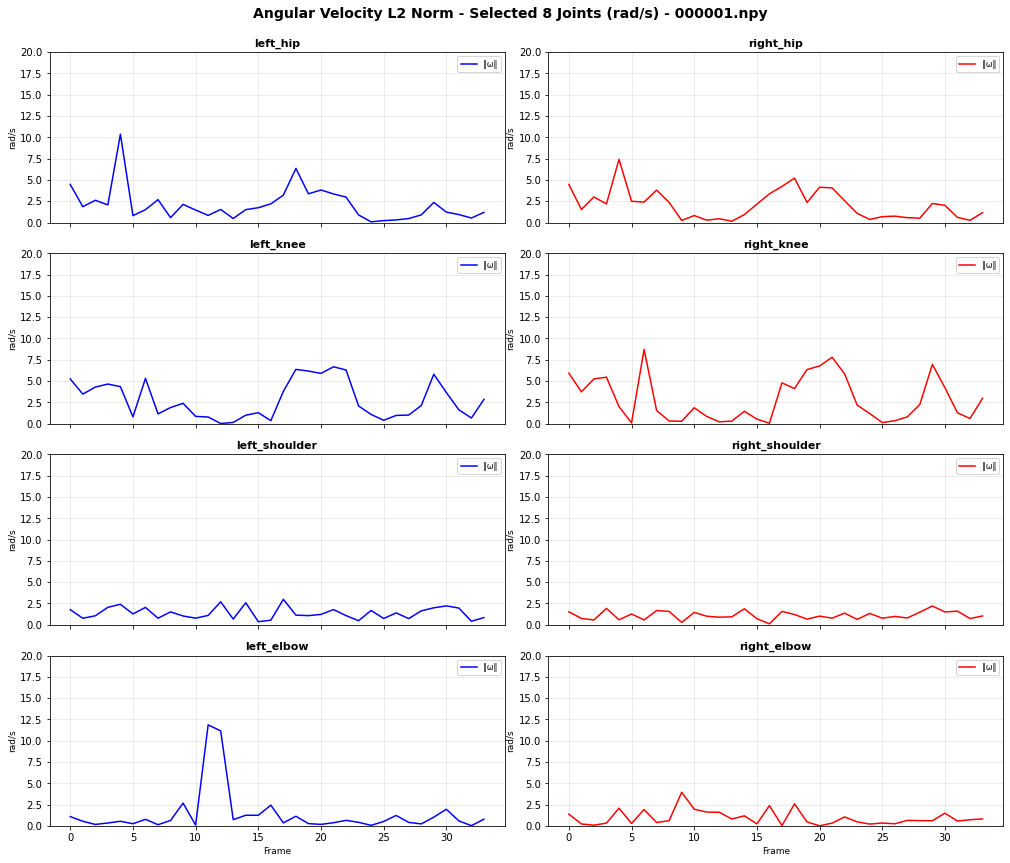


File: 000001.npy
Shape: (34, 8, 1)
Expected: (T-1, 8, 1)

L2 norm per joint:
  left_hip            : ‖wx, wz‖
  right_hip           : ‖wx, wz‖
  left_knee           : ‖wx‖
  right_knee          : ‖wx‖
  left_shoulder       : ‖wx, wz‖
  right_shoulder      : ‖wx, wz‖
  left_elbow          : ‖wy‖
  right_elbow         : ‖wy‖


In [12]:
# L2 norm 시각화 (한 줄씩만 표시)
omega_l2_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/05_omega_l2norm'

file_name = "000001.npy"
omega_path = os.path.join(omega_l2_dir, file_name)

omega_l2 = np.load(omega_path)  # (T-1, 8, 1)

T1, J, _ = omega_l2.shape
assert J == 8, f"Expected 8 joints, got {J}"

t = np.arange(T1)

# 4행 2열 레이아웃 (좌/우 대칭)
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)

joint_pairs = [
    (0, 1),  # hip
    (2, 3),  # knee
    (4, 5),  # shoulder
    (6, 7),  # elbow
]

for row, (left_idx, right_idx) in enumerate(joint_pairs):
    # 왼쪽 관절
    ax_left = axes[row, 0]
    ax_left.plot(t, omega_l2[:, left_idx, 0], color='blue', linewidth=1.5, label='‖ω‖')
    ax_left.set_title(selected_joint_names[left_idx], fontsize=11, fontweight='bold')
    ax_left.set_ylim(0.0, 20.0)  # L2 norm은 항상 양수
    ax_left.grid(True, alpha=0.3)
    ax_left.legend(loc="upper right", fontsize=8)
    ax_left.set_ylabel("rad/s", fontsize=9)
    
    # 오른쪽 관절
    ax_right = axes[row, 1]
    ax_right.plot(t, omega_l2[:, right_idx, 0], color='red', linewidth=1.5, label='‖ω‖')
    ax_right.set_title(selected_joint_names[right_idx], fontsize=11, fontweight='bold')
    ax_right.set_ylim(0.0, 20.0)
    ax_right.grid(True, alpha=0.3)
    ax_right.legend(loc="upper right", fontsize=8)
    ax_right.set_ylabel("rad/s", fontsize=9)
    
    # 하단 행에만 x축 레이블
    if row == 3:
        ax_left.set_xlabel("Frame", fontsize=9)
        ax_right.set_xlabel("Frame", fontsize=9)

fig.suptitle(f"Angular Velocity L2 Norm - Selected 8 Joints (rad/s) - {file_name}", 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"File: {file_name}")
print(f"Shape: {omega_l2.shape}")
print(f"Expected: (T-1, 8, 1)")
print(f"\nL2 norm per joint:")
for i, joint in enumerate(selected_joint_names):
    axes = joint_axis_config[joint]
    axis_names = ['wx', 'wy', 'wz']
    selected_axes = [axis_names[j] for j in axes]
    print(f"  {joint:20s}: ‖{', '.join(selected_axes)}‖")
print(f"{'='*60}")

## 6. 칼만 필터링

In [8]:
## 6. 칼만 필터링

from pykalman import KalmanFilter

def apply_kalman_filter_omega(data, process_variance=5e-2, measurement_variance=1e-1):
    """
    각속도 L2 norm 데이터에 Kalman filter 적용하여 이상치 제거
    
    Args:
        data: (T-1, 8, 1) 형태의 각속도 L2 norm 데이터 (rad/s)
        process_variance: 프로세스 노이즈 분산 (작을수록 부드러움)
        measurement_variance: 측정 노이즈 분산 (클수록 관측을 덜 신뢰)
    
    Returns:
        filtered: (T-1, 8, 1) 필터링된 각속도 L2 norm
    """
    if data.shape[0] == 0:
        return data.copy()
    
    filtered = np.zeros_like(data)
    
    for j in range(data.shape[1]):  # 8개 관절
        # 1D Kalman Filter 설정
        kf = KalmanFilter(
            transition_matrices=[1],           # 상태 전이 행렬
            observation_matrices=[1],          # 관측 행렬
            initial_state_mean=data[0, j, 0],  # 초기 조건
            initial_state_covariance=1,        # 초기 상태 공분산
            observation_covariance=measurement_variance,  # 관측 노이즈
            transition_covariance=process_variance        # 프로세스 노이즈
        )
        
        # 필터링 수행
        state_means, _ = kf.smooth(data[:, j, 0])
        filtered[:, j, 0] = state_means[:, 0]
    
    return filtered

단일 파일 칼만 필터링 이상치 제거

In [26]:
## 단일 파일 칼만 필터링 이상치 제거

# 테스트 파일 로드
input_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/05_omega_l2norm'
test_file = "M007238.npy"

test_path = os.path.join(input_dir, test_file)

print(f"Testing Kalman filter on: {test_file}")
omega_orig = np.load(test_path)  # (T-1, 8, 1)
print(f"Original shape: {omega_orig.shape}")
print(f"Original range: [{omega_orig.min():.4f}, {omega_orig.max():.4f}]")

# Kalman 필터링 적용
print("\nApplying Kalman filter...")
omega_filt = apply_kalman_filter_omega(
    omega_orig,
    process_variance=5e-2,
    measurement_variance=1e-1
)

print(f"\nFiltered shape: {omega_filt.shape}")
print(f"Filtered range: [{omega_filt.min():.4f}, {omega_filt.max():.4f}]")
print("✓ Single file test complete!")

Testing Kalman filter on: M007238.npy
Original shape: (198, 8, 1)
Original range: [0.0000, 1.1415]

Applying Kalman filter...

Filtered shape: (198, 8, 1)
Filtered range: [0.0004, 0.7561]
✓ Single file test complete!


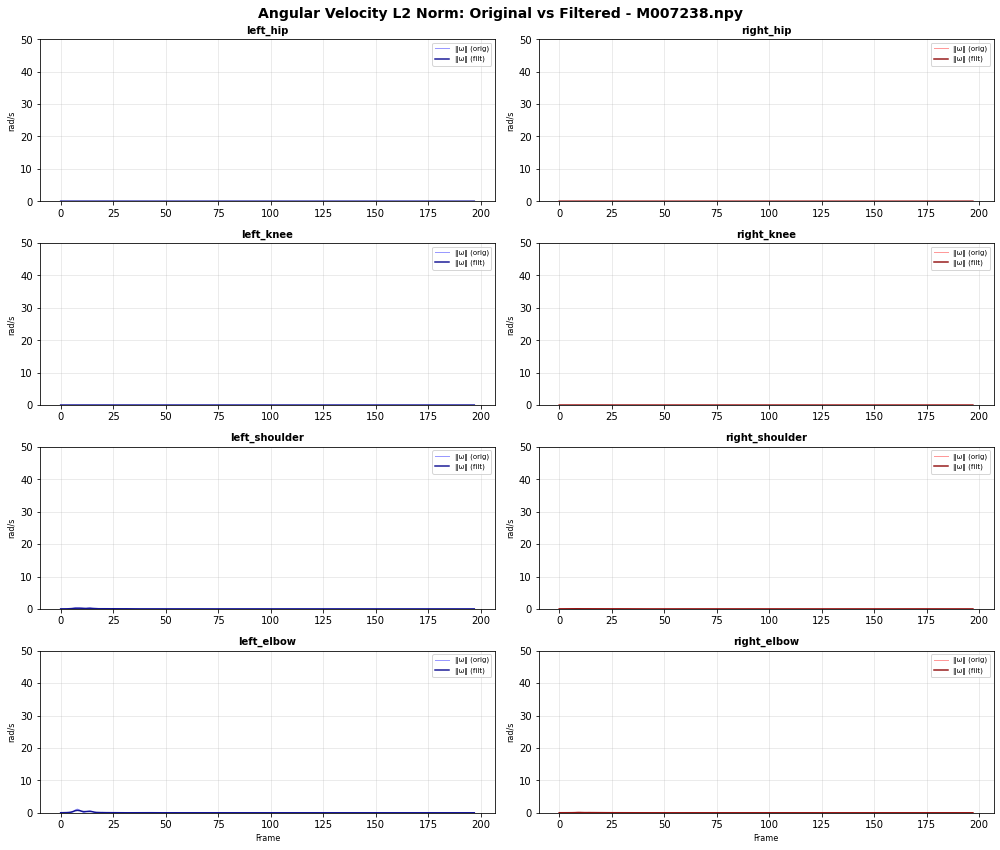

In [27]:
# 필터링 전후 시각화 비교 (단일 파일)
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

t = np.arange(omega_orig.shape[0])

joint_pairs = [
    (0, 1),  # hip
    (2, 3),  # knee
    (4, 5),  # shoulder
    (6, 7),  # elbow
]

for idx, (left_idx, right_idx) in enumerate(joint_pairs):
    # 왼쪽 관절
    ax_left = axes[idx * 2]
    ax_left.plot(t, omega_orig[:, left_idx, 0], label="‖ω‖ (orig)", 
                 alpha=0.4, linewidth=1.0, color='blue')
    ax_left.plot(t, omega_filt[:, left_idx, 0], label="‖ω‖ (filt)", 
                 alpha=0.9, linewidth=1.5, color='darkblue')
    ax_left.set_title(f"{selected_joint_names[left_idx]}", fontsize=10, fontweight='bold')
    ax_left.set_ylabel("rad/s", fontsize=8)
    ax_left.legend(fontsize=7, loc='upper right')
    ax_left.grid(True, alpha=0.3)
    ax_left.set_ylim(0.0, 50.0)
    
    # 오른쪽 관절
    ax_right = axes[idx * 2 + 1]
    ax_right.plot(t, omega_orig[:, right_idx, 0], label="‖ω‖ (orig)", 
                  alpha=0.4, linewidth=1.0, color='red')
    ax_right.plot(t, omega_filt[:, right_idx, 0], label="‖ω‖ (filt)", 
                  alpha=0.9, linewidth=1.5, color='darkred')
    ax_right.set_title(f"{selected_joint_names[right_idx]}", fontsize=10, fontweight='bold')
    ax_right.set_ylabel("rad/s", fontsize=8)
    ax_right.legend(fontsize=7, loc='upper right')
    ax_right.grid(True, alpha=0.3)
    ax_right.set_ylim(0.0, 50.0)
    
    # 하단 행에만 x축 레이블
    if idx == 3:
        ax_left.set_xlabel("Frame", fontsize=8)
        ax_right.set_xlabel("Frame", fontsize=8)

fig.suptitle(f"Angular Velocity L2 Norm: Original vs Filtered - {test_file}", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

전체 파일에 대해 칼만 필터링 진행. 이상치 제거

In [147]:
## 전체 파일에 대해 칼만 필터링 진행

input_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/05_omega_l2norm'
output_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/06_omega_filtered'
os.makedirs(output_dir, exist_ok=True)

files = sorted(glob.glob(os.path.join(input_dir, '*.npy')))

print(f"Total files: {len(files)}")
print("Applying Kalman filter to L2 norm data...\n")

skipped = []

for f in tqdm(files, desc="Filtering with Kalman"):
    filename = os.path.basename(f)
    out_f = os.path.join(output_dir, filename)
    
    omega = np.load(f)  # (T-1, 8, 1)
    
    # 빈 파일 처리
    if omega.shape[0] == 0:
        skipped.append(filename)
        np.save(out_f, omega)
        continue
    
    # Kalman 필터링
    omega_filtered = apply_kalman_filter_omega(
        omega, 
        process_variance=1e-2,    # 작을수록 부드러움
        measurement_variance=5e-1  # 클수록 이상치 제거 강함
    )
    
    # 저장
    np.save(out_f, omega_filtered.astype(np.float32))

print(f"\nFiltering complete!")
print(f"Saved to: {output_dir}")

if skipped:
    print(f"\nSkipped {len(skipped)} empty files")

Filtering with Kalman:   0%|          | 0/29228 [00:00<?, ?it/s]

Total files: 29228
Applying Kalman filter to L2 norm data...



Filtering with Kalman: 100%|██████████| 29228/29228 [2:07:20<00:00,  3.83it/s]  


Filtering complete!
Saved to: D:/HumanML3D-SMPL-main/HumanML3D/06_omega_filtered

Skipped 4 empty files


## 7. 관절별, 축별 정규화 (0~1)

In [171]:
## 7. 관절별 정규화 (0~1) - Global Min/Max 기반

input_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/06_omega_filtered'
output_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/07_omega_normalized'
os.makedirs(output_dir, exist_ok=True)

files = sorted(glob.glob(os.path.join(input_dir, '*.npy')))

print(f"Total files: {len(files)}")
print("Step 1: Finding global min/max per joint...\n")

# 1단계: Global min/max 찾기 (파일명 추적 포함)
global_min = np.full(8, np.inf)   # (8,)
global_max = np.full(8, -np.inf)  # (8,)
min_files = [''] * 8  # 최소값을 가진 파일명
max_files = [''] * 8  # 최대값을 가진 파일명

for f in tqdm(files, desc="Scanning for global min/max"):
    data = np.load(f)  # (T-1, 8, 1)
    
    if data.shape[0] == 0:
        continue
    
    filename = os.path.basename(f)
    
    for j in range(8):
        joint_data = data[:, j, 0]
        joint_min = joint_data.min()
        joint_max = joint_data.max()
        
        # 최소값 업데이트
        if joint_min < global_min[j]:
            global_min[j] = joint_min
            min_files[j] = filename
        
        # 최대값 업데이트
        if joint_max > global_max[j]:
            global_max[j] = joint_max
            max_files[j] = filename

print("\n" + "="*80)
print("Global Statistics (with source files):")
print("="*80)
print(f"{'Joint':<20} {'Min':<12} {'Min File':<15} {'Max':<12} {'Max File':<15}")
print("-"*80)
for j in range(8):
    range_val = global_max[j] - global_min[j]
    print(f"{selected_joint_names[j]:<20} "
          f"{global_min[j]:>8.4f}    {min_files[j]:<15} "
          f"{global_max[j]:>8.4f}    {max_files[j]:<15}")
print("="*80)

# 2단계: 정규화 및 저장
print("\nStep 2: Normalizing and saving...\n")

for f in tqdm(files, desc="Normalizing to [0, 1]"):
    filename = os.path.basename(f)
    out_f = os.path.join(output_dir, filename)
    
    data = np.load(f)  # (T-1, 8, 1)
    
    if data.shape[0] == 0:
        np.save(out_f, data)
        continue
    
    # 관절별 정규화
    normalized = np.zeros_like(data)
    
    for j in range(8):
        joint_data = data[:, j, 0]
        range_val = global_max[j] - global_min[j]
        
        if range_val > 1e-8:  # 0으로 나누기 방지
            normalized[:, j, 0] = (joint_data - global_min[j]) / range_val
        else:
            normalized[:, j, 0] = 0.0  # range가 0이면 0으로 설정
    
    np.save(out_f, normalized.astype(np.float32))

print(f"\n✓ Normalization complete!")
print(f"Saved to: {output_dir}")

# 3단계: 검증
print("\nStep 3: Verification...")
test_file = files[0]
test_name = os.path.basename(test_file)

orig_data = np.load(test_file)
norm_data = np.load(os.path.join(output_dir, test_name))

print(f"\nTest file: {test_name}")
print(f"Original range: [{orig_data.min():.4f}, {orig_data.max():.4f}]")
print(f"Normalized range: [{norm_data.min():.4f}, {norm_data.max():.4f}]")
print(f"Expected: [0.0000, 1.0000]")

if norm_data.min() >= -1e-6 and norm_data.max() <= 1.0 + 1e-6:
    print("✓ Normalization verified!")
else:
    print("⚠ Warning: Normalized values out of expected range")

Scanning for global min/max:   1%|          | 236/29224 [00:00<00:12, 2359.29it/s]

Total files: 29224
Step 1: Finding global min/max per joint...



Normalizing to [0, 1]:   1%|          | 240/29224 [00:00<00:24, 1190.43it/s]


Global Statistics (with source files):
Joint                Min          Min File        Max          Max File       
--------------------------------------------------------------------------------
left_hip               0.0009    002275.npy        7.3561    M001894.npy    
right_hip              0.0009    M002275.npy       7.3561    001894.npy     
left_knee              0.0005    011457.npy       10.9711    013182.npy     
right_knee             0.0005    M011457.npy      10.9711    M013182.npy    
left_shoulder          0.0018    M011457.npy       8.9261    000668.npy     
right_shoulder         0.0018    011457.npy        8.9261    M000668.npy    
left_elbow             0.0014    M002416.npy      10.5047    M008863.npy    
right_elbow            0.0014    002416.npy       10.5047    008863.npy     

Step 2: Normalizing and saving...



Normalizing to [0, 1]: 100%|██████████| 29224/29224 [00:31<00:00, 934.20it/s] 



✓ Normalization complete!
Saved to: D:/HumanML3D-SMPL-main/HumanML3D/07_omega_normalized

Step 3: Verification...

Test file: 000000.npy
Original range: [0.0069, 5.8373]
Normalized range: [0.0006, 0.5320]
Expected: [0.0000, 1.0000]
✓ Normalization verified!


In [172]:
# 필터링 후 → 정규화 전후 통계 비교
file_name = "000000.npy"

# 필터링된 원본
omega_filt = np.load(os.path.join('D:/HumanML3D-SMPL-main/HumanML3D/06_omega_filtered', file_name))
# 정규화된 데이터
omega_norm = np.load(os.path.join(output_dir, file_name))

print(f"File: {file_name}")
print(f"Shape: {omega_filt.shape}, {omega_norm.shape}")
print(f"Expected: (T-1, 8, 1)\n")

# 통계 비교
print("="*80)
print(f"{'Joint':<25} {'Filtered (rad/s)':<30} {'Normalized [0,1]':<30}")
print("="*80)

for j in range(8):
    filt_data = omega_filt[:, j, 0]
    norm_data = omega_norm[:, j, 0]
    
    filt_min = filt_data.min()
    filt_max = filt_data.max()
    filt_mean = filt_data.mean()
    filt_std = filt_data.std()
    
    norm_min = norm_data.min()
    norm_max = norm_data.max()
    norm_mean = norm_data.mean()
    norm_std = norm_data.std()
    
    print(f"{selected_joint_names[j]:<25}")
    print(f"  Filtered:   min={filt_min:>6.3f} max={filt_max:>6.3f} μ={filt_mean:>6.3f} σ={filt_std:>6.3f}")
    print(f"  Normalized: min={norm_min:>6.3f} max={norm_max:>6.3f} μ={norm_mean:>6.3f} σ={norm_std:>6.3f}")
    print()

print("="*80)

File: 000000.npy
Shape: (115, 8, 1), (115, 8, 1)
Expected: (T-1, 8, 1)

Joint                     Filtered (rad/s)               Normalized [0,1]              
left_hip                 
  Filtered:   min= 0.016 max= 2.422 μ= 0.722 σ= 0.770
  Normalized: min= 0.002 max= 0.329 μ= 0.098 σ= 0.105

right_hip                
  Filtered:   min= 0.009 max= 1.408 μ= 0.510 σ= 0.504
  Normalized: min= 0.001 max= 0.191 μ= 0.069 σ= 0.069

left_knee                
  Filtered:   min= 0.013 max= 5.837 μ= 1.510 σ= 1.831
  Normalized: min= 0.001 max= 0.532 μ= 0.138 σ= 0.167

right_knee               
  Filtered:   min= 0.007 max= 1.198 μ= 0.446 σ= 0.451
  Normalized: min= 0.001 max= 0.109 μ= 0.041 σ= 0.041

left_shoulder            
  Filtered:   min= 0.012 max= 1.051 μ= 0.395 σ= 0.357
  Normalized: min= 0.001 max= 0.118 μ= 0.044 σ= 0.040

right_shoulder           
  Filtered:   min= 0.013 max= 1.717 μ= 0.604 σ= 0.625
  Normalized: min= 0.001 max= 0.192 μ= 0.067 σ= 0.070

left_elbow               
  Fi

In [173]:
# 관절별 최고/최저 속도 파일 찾기
print("\n" + "="*80)
print("Top 5 Fastest & Slowest Motions per Joint")
print("="*80)

for j in range(8):
    joint_name = selected_joint_names[j]
    
    # 모든 파일의 해당 관절 평균 속도 계산
    motion_speeds = []
    
    for f in files:
        data = np.load(f)  # (T-1, 8, 1)
        
        if data.shape[0] == 0:
            continue
        
        # 해당 관절의 평균 속도 (정규화 전 데이터 기준)
        avg_speed = data[:, j, 0].mean()
        motion_speeds.append((os.path.basename(f), avg_speed))
    
    # 속도 기준 정렬
    motion_speeds.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\n{joint_name.upper()}")
    print("-" * 80)
    
    # Top 5 fastest
    print("  🔥 Top 5 Fastest:")
    for rank, (fname, speed) in enumerate(motion_speeds[:5], 1):
        print(f"    {rank}. {fname:20s} - {speed:>8.4f} rad/s")
    
    # Top 5 slowest
    print("  🐢 Top 5 Slowest:")
    for rank, (fname, speed) in enumerate(motion_speeds[-5:][::-1], 1):
        print(f"    {rank}. {fname:20s} - {speed:>8.4f} rad/s")

print("\n" + "="*80)


Top 5 Fastest & Slowest Motions per Joint

LEFT_HIP
--------------------------------------------------------------------------------
  🔥 Top 5 Fastest:
    1. 008353.npy           -   5.8222 rad/s
    2. 003216.npy           -   5.2356 rad/s
    3. M001894.npy          -   5.2322 rad/s
    4. 004173.npy           -   5.2210 rad/s
    5. M001161.npy          -   5.2208 rad/s
  🐢 Top 5 Slowest:
    1. M007238.npy          -   0.0055 rad/s
    2. 014211.npy           -   0.0056 rad/s
    3. 011457.npy           -   0.0056 rad/s
    4. M011457.npy          -   0.0057 rad/s
    5. 005001.npy           -   0.0062 rad/s

RIGHT_HIP
--------------------------------------------------------------------------------
  🔥 Top 5 Fastest:
    1. M008353.npy          -   5.8222 rad/s
    2. M003216.npy          -   5.2356 rad/s
    3. 001894.npy           -   5.2322 rad/s
    4. M004173.npy          -   5.2210 rad/s
    5. 001161.npy           -   5.2208 rad/s
  🐢 Top 5 Slowest:
    1. 007238.npy      

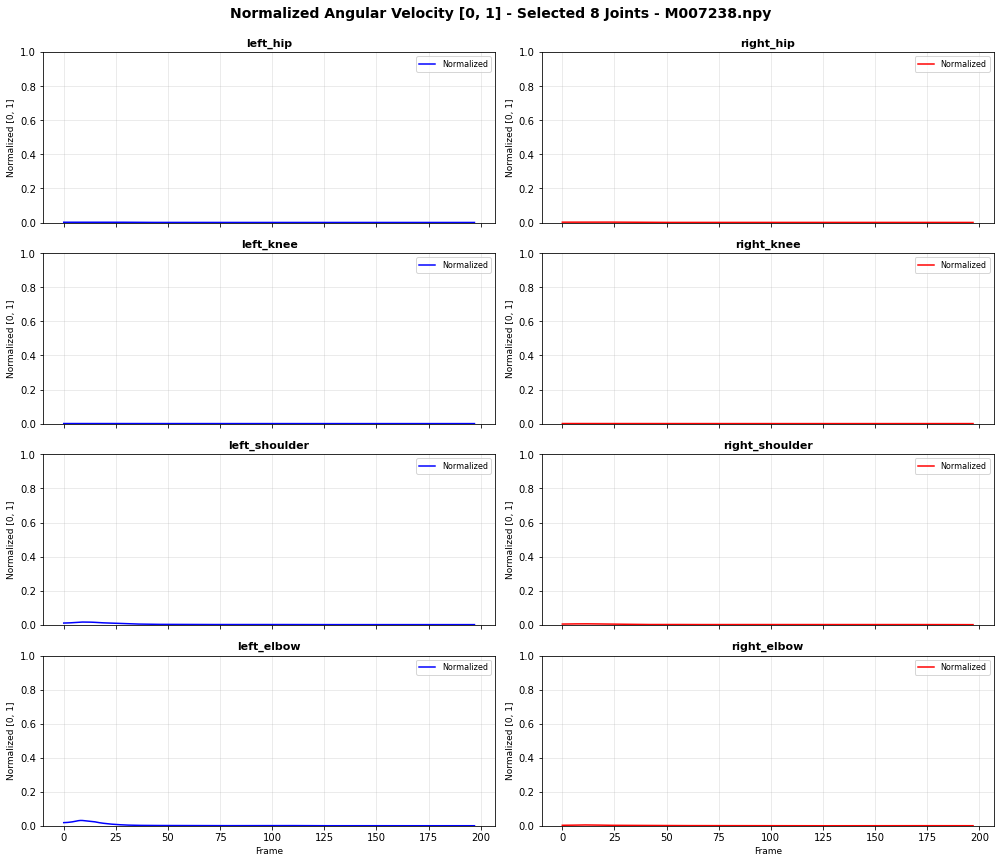


File: M007238.npy
Shape: (198, 8, 1)
Expected: (T-1, 8, 1)

Normalized statistics per joint:
Joint                Min      Max      Mean     Std     
------------------------------------------------------------
left_hip             0.0002  0.0024  0.0006  0.0006
right_hip            0.0003  0.0031  0.0008  0.0007
left_knee            0.0000  0.0005  0.0002  0.0001
right_knee           0.0001  0.0009  0.0002  0.0002
left_shoulder        0.0005  0.0155  0.0027  0.0040
right_shoulder       0.0003  0.0051  0.0013  0.0013
left_elbow           0.0004  0.0313  0.0037  0.0072
right_elbow          0.0003  0.0050  0.0012  0.0012


In [23]:
## 8. 정규화된 데이터 시각화

norm_dir = 'D:/HumanML3D-SMPL-main/HumanML3D/07_omega_normalized'

# 시각화할 파일 선택
file_name = "M007238.npy"
norm_path = os.path.join(norm_dir, file_name)

omega_norm = np.load(norm_path)  # (T-1, 8, 1)

T1, J, _ = omega_norm.shape
assert J == 8, f"Expected 8 joints, got {J}"

t = np.arange(T1)

# 4행 2열 레이아웃 (좌/우 대칭)
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)

joint_pairs = [
    (0, 1),  # hip
    (2, 3),  # knee
    (4, 5),  # shoulder
    (6, 7),  # elbow
]

for row, (left_idx, right_idx) in enumerate(joint_pairs):
    # 왼쪽 관절
    ax_left = axes[row, 0]
    ax_left.plot(t, omega_norm[:, left_idx, 0], color='blue', linewidth=1.5, label='Normalized')
    ax_left.set_title(selected_joint_names[left_idx], fontsize=11, fontweight='bold')
    ax_left.set_ylim(0.0, 1.0)  # 정규화된 범위 [0, 1]
    ax_left.grid(True, alpha=0.3)
    ax_left.legend(loc="upper right", fontsize=8)
    ax_left.set_ylabel("Normalized [0, 1]", fontsize=9)
    
    # 오른쪽 관절
    ax_right = axes[row, 1]
    ax_right.plot(t, omega_norm[:, right_idx, 0], color='red', linewidth=1.5, label='Normalized')
    ax_right.set_title(selected_joint_names[right_idx], fontsize=11, fontweight='bold')
    ax_right.set_ylim(0.0, 1.0)  # 정규화된 범위 [0, 1]
    ax_right.grid(True, alpha=0.3)
    ax_right.legend(loc="upper right", fontsize=8)
    ax_right.set_ylabel("Normalized [0, 1]", fontsize=9)
    
    # 하단 행에만 x축 레이블
    if row == 3:
        ax_left.set_xlabel("Frame", fontsize=9)
        ax_right.set_xlabel("Frame", fontsize=9)

fig.suptitle(f"Normalized Angular Velocity [0, 1] - Selected 8 Joints - {file_name}", 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# 통계 출력
print(f"\n{'='*60}")
print(f"File: {file_name}")
print(f"Shape: {omega_norm.shape}")
print(f"Expected: (T-1, 8, 1)")
print(f"\nNormalized statistics per joint:")
print(f"{'Joint':<20} {'Min':<8} {'Max':<8} {'Mean':<8} {'Std':<8}")
print(f"{'-'*60}")
for i, joint in enumerate(selected_joint_names):
    joint_data = omega_norm[:, i, 0]
    print(f"{joint:<20} {joint_data.min():>6.4f}  {joint_data.max():>6.4f}  "
          f"{joint_data.mean():>6.4f}  {joint_data.std():>6.4f}")
print(f"{'='*60}")